# Plausible DFS audit graphs: construction, plotting, and audits

This notebook walks through the full pipeline on Portland's 2024 City
Council election for District 1 (16 candidates, 3 seats, N = 42,678) —
the same election as Figure 1 of the writeup:

1. build a **plausible audit graph** by depth-first search at a fixed
   Margin of Insecurity (writeup §2.1–2.2),
2. plot it,
3. run a **mismatch-based audit** (§3.2), and
4. run a **Delta-method audit** (§3.3).

Construction, plotting, and the Delta audit finish in seconds; the
mismatch audit samples a large share of the ballots and takes a few
minutes (see §4 below for why). For the batch-elimination (seeded) construction used on large
elections, see `victoria_v2.ipynb`.


In [1]:
# Make the repo root importable when the kernel cwd is notebooks/.
import os, sys

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)


## 1. Load a ballot profile

Profiles are stored in the Scottish-election csv format under `data/`
(see `data/README.md`). `load_numpy` returns the profile together with
the number of seats recorded in the file.


In [2]:
from src.election_graphs.numpy_profile import load_numpy

profile, m, *_ = load_numpy(
    os.path.join(repo_root, "data", "portland", "portland_d1_2024.csv")
)
print(f"C = {len(profile.candidates)} candidates, m = {m} seats, "
      f"N = {round(profile.total_ballot_wt)} ballots")


C = 16 candidates, m = 3 seats, N = 42678 ballots


## 2. Build the plausible graph

The constructor starts from the root (all candidates hopeful) and follows
every edge that could have been chosen by the true tabulation if the
tallies of its base vertex were shifted by less than the Margin of
Insecurity `MoI` — here the value from the results table, M = 671.
`add_natural_edges` guarantees the reported election path is present,
and `coherence_check` verifies that every terminal vertex seats the same
winner set, which is what makes the graph auditable.


In [3]:
from src.wigm_graphs.graph_wigm import WIGMGraphConstructor

constructor = WIGMGraphConstructor(
    profile,
    m=m,
    MoI=671,
    memory_lite=True,
    simultaneous=True,
)
constructor.build()
constructor.add_natural_edges()
constructor.assign_tightest_margins()
constructor.coherence_check()


Coherence check passed.
  terminal vertices: 10
  winner set: ['Jamie Dunphy', 'Candace Avalos', 'Loretta Smith']


True

## 3. Plot it

Layers run left to right (one per tabulation round); vertices are
colour-coded by how many winners they have seated. Compare with
Figure 1 of the writeup: the early layers carry most of the vertices,
the pattern that motivates batch elimination for larger elections.


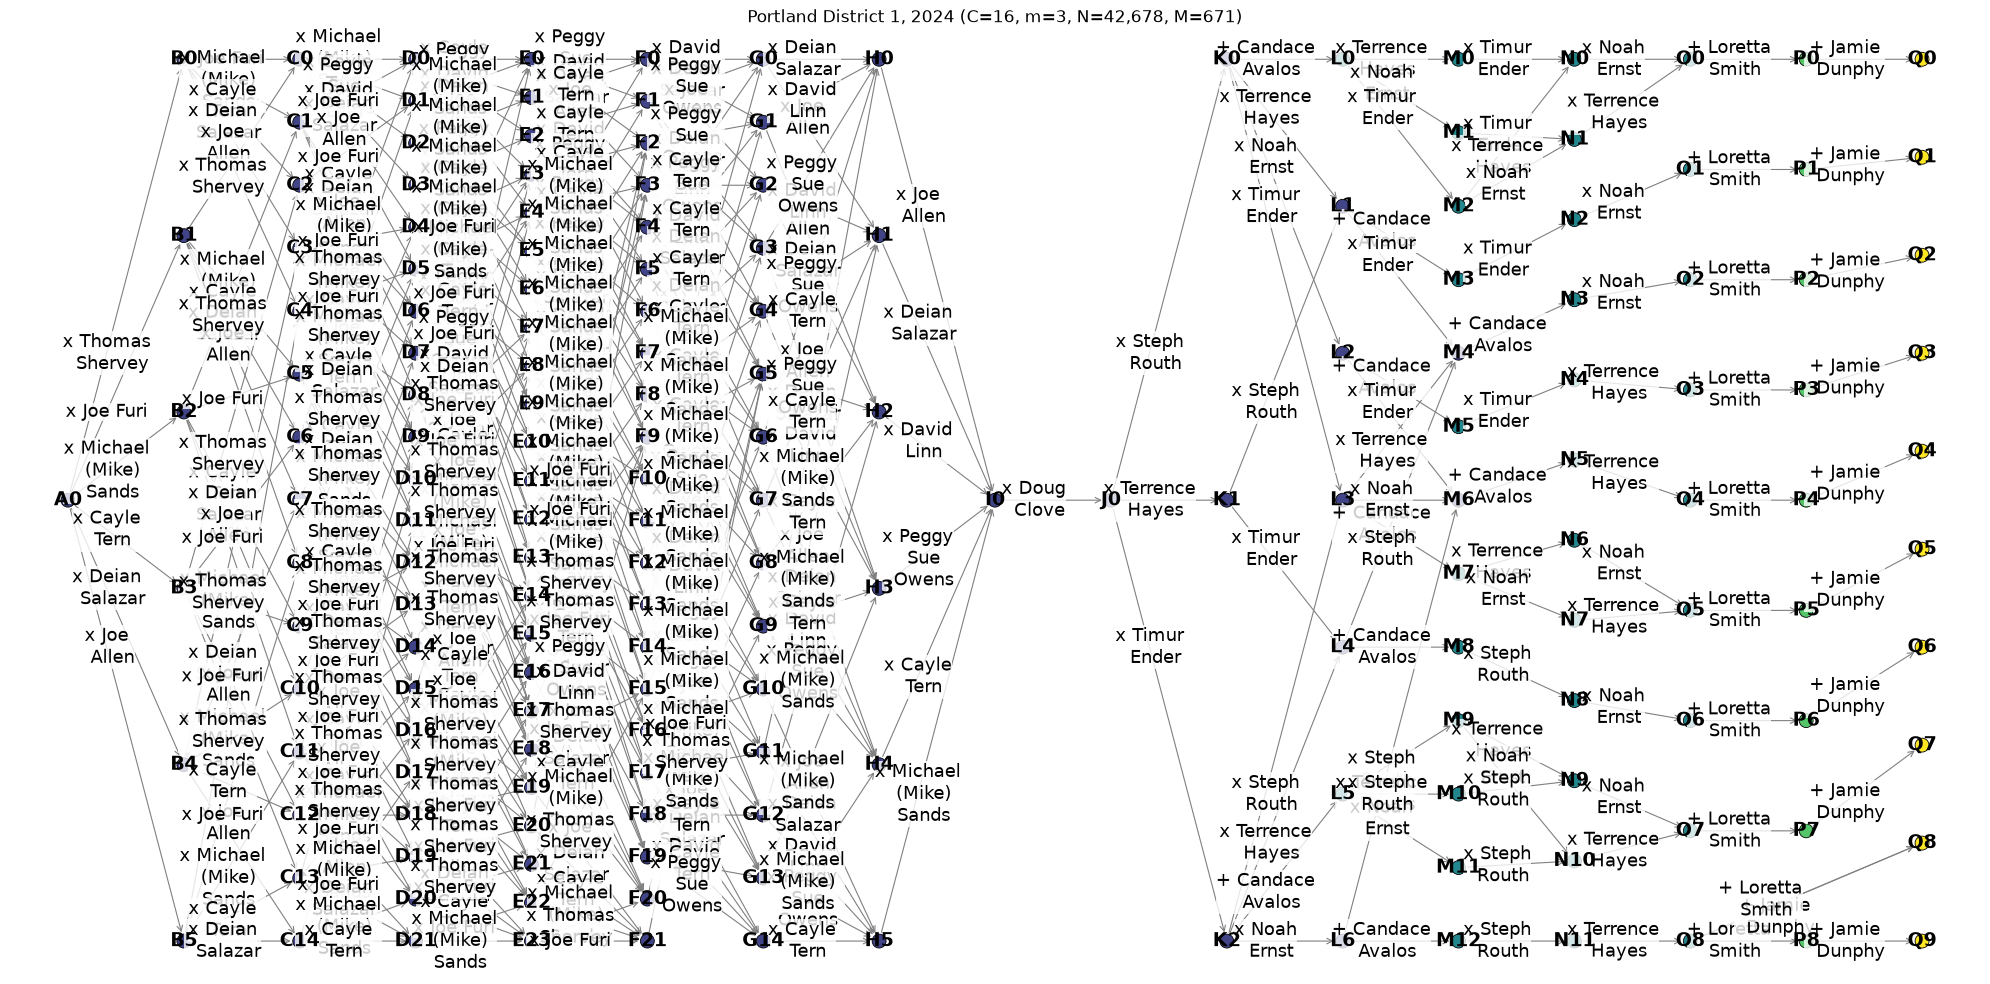

In [4]:
from src.plotting import plot_wigm_graph

plot_wigm_graph(
    constructor,
    figsize=(20, 10),
    node_size=100,
    font_size=14,
    label_vertices=True,
    plot_horizontal=True,
    title="Portland District 1, 2024 (C=16, m=3, N=42,678, M=671)",
)


## 4. Mismatch-based audit

The driver noises the CVRs (2% mismatches, the protocol of §3.4), builds
one COBRA noise-filter compiler per escape edge, and broadcasts sampled
ballot comparisons to all of them. The audit certifies when every
compiler has rejected its local null at risk level alpha = 5%; it fails
if the sample cap (half the ballots) is reached first.

District 1 is a hard case for the mismatch method: its diluted margin
M/N = 1.6% is comparable to the 2% mismatch rate, so certification —
when it happens at all — takes a sample orders of magnitude larger than
the Delta method needs (§5). At realistic real-world mismatch rates
(typically below 0.2%) the mismatch audit performs far better.


In [5]:
from src.test_processes.driver import GlobalAuditDriver

mismatch_driver = GlobalAuditDriver(
    constructor,
    noise_level=0.02,
    fractional_sample_size=0.5,
    seed=0,
    compiler_type="noise",
    simultaneous=True,
    alpha=0.05,
    print_diagnostics_every=5_000,
)
print(f"escape-edge compilers: {len(mismatch_driver.compilers)}")

certified = mismatch_driver.run(constructor.ballot_matrix)
print(
    f"certified: {certified} — "
    f"{len(mismatch_driver.certified)}/{len(mismatch_driver.compilers)} "
    f"compilers passed after {mismatch_driver.i} ballots"
)


Removed 8 duplicate compilers.
escape-edge compilers: 2565


Audit diagnostic after 5000 samples: 3 compilers remain below threshold (2562/2565 certified).
  N1-E2: M=0.28504, escape=ELIMINATE 2:Jamie Dunphy, margin=335.795254496712, kind=CobraNoiseFilterCompiler
  M8-E2: M=8.97473, escape=ELIMINATE 2:Jamie Dunphy, margin=362.92623974309527, kind=CobraNoiseFilterCompiler
  N4-E2: M=12.7544, escape=ELIMINATE 2:Jamie Dunphy, margin=403.8074149406266, kind=CobraNoiseFilterCompiler
Audit diagnostic after 10000 samples: 1 compilers remain below threshold (2564/2565 certified).
  N1-E2: M=0.294882, escape=ELIMINATE 2:Jamie Dunphy, margin=335.795254496712, kind=CobraNoiseFilterCompiler
Audit diagnostic after 15000 samples: 1 compilers remain below threshold (2564/2565 certified).
  N1-E2: M=4.01849, escape=ELIMINATE 2:Jamie Dunphy, margin=335.795254496712, kind=CobraNoiseFilterCompiler
Audit certified all compilers. Final sample size: 15773.
Last compilers to pass threshold:
  N4-E2: M=20.0139, escape=ELIMINATE 2:Jamie Dunphy, margin=403.8074149406266,

## 5. Delta-method audit

The Delta driver instead draws a fixed-size sample and builds a Wald
confidence interval for each escape edge's critical margin, using the
symbolic margin machinery of `src/test_processes/symbolic_equations.py`.
The fraction below (1/60 of ballots, 711 of them) is the certifying
sample size from the results table; the audit passes iff every interval
excludes the escape — succeeding where the mismatch audit failed.


In [6]:
from src.test_processes.delta_method import DeltaMethodAuditDriver

delta_driver = DeltaMethodAuditDriver(
    constructor,
    fractional_sample_size=1 / 60,
    noise_level=0.02,
    seed=0,
    alpha=0.05,
    verbose=True,
)
success = delta_driver.run()
print(f"certified: {success} with a sample of {delta_driver.sample_size} ballots")


Starting Delta-Method audit: 2555 escape edges, 148 vertices, n=711, alpha=0.05, alpha_K=0.005, source=implicit sampler, seeded=False.
Layer 0 (1/14): 26 escape edges across 1 vertices.
  Vertex A0: 26 escape edges.
    [1/26; vertex 1/26; overall 1/2555] A0-E0 PASS: escape=ELIMINATE Steph Routh(0); assert Steph Routh > Joe Furi; CI=[3,210.58, inf), estimate=3,537.00, recorded=3,537.00, SE=192.53, discrepancies=0, K<=314.
    [2/26; vertex 2/26; overall 2/2555] A0-W0 PASS: escape=ELECT Steph Routh(0); assert quota > Steph Routh; CI=[6,445.58, inf), estimate=6,772.00, recorded=6,772.00, SE=192.53, discrepancies=0, K<=314.
    [3/26; vertex 3/26; overall 3/2555] A0-W1 PASS: escape=ELECT Thomas Shervey(1); assert quota > Thomas Shervey; CI=[9,956.58, inf), estimate=10,283.00, recorded=10,283.00, SE=192.53, discrepancies=0, K<=314.
    [4/26; vertex 4/26; overall 4/2555] A0-E2 PASS: escape=ELIMINATE Jamie Dunphy(2); assert Jamie Dunphy > Joe Furi; CI=[4,380.58, inf), estimate=4,707.00, rec

    [172/498; vertex 12/20; overall 1200/2555] E8-W9 PASS: escape=ELECT Terrence Hayes(9); assert quota > Terrence Hayes; CI=[6,217.63, inf), estimate=6,604.03, recorded=6,544.00, SE=227.91, discrepancies=1, K<=440.
    [173/498; vertex 13/20; overall 1201/2555] E8-W10 PASS: escape=ELECT David Linn(10); assert quota > David Linn; CI=[9,037.58, inf), estimate=9,364.00, recorded=9,364.00, SE=192.53, discrepancies=0, K<=314.
    [174/498; vertex 14/20; overall 1202/2555] E8-E11 PASS: escape=ELIMINATE Noah Ernst(11); assert Noah Ernst > Deian Salazar; CI=[3,070.58, inf), estimate=3,397.00, recorded=3,397.00, SE=192.53, discrepancies=0, K<=314.
    [175/498; vertex 15/20; overall 1203/2555] E8-W11 PASS: escape=ELECT Noah Ernst(11); assert quota > Noah Ernst; CI=[6,128.58, inf), estimate=6,455.00, recorded=6,455.00, SE=192.53, discrepancies=0, K<=314.
    [176/498; vertex 16/20; overall 1204/2555] E8-E12 PASS: escape=ELIMINATE Timur Ender(12); assert Timur Ender > Deian Salazar; CI=[2,579.58

    [6/47; vertex 6/7; overall 2378/2555] L0-E14 PASS: escape=ELIMINATE Loretta Smith(14); assert Loretta Smith > Timur Ender; CI=[1,917.88, inf), estimate=2,373.83, recorded=2,450.48, SE=268.94, discrepancies=2, K<=550.
    [7/47; vertex 7/7; overall 2379/2555] L0-W14 PASS: escape=ELECT Loretta Smith(14); assert quota > Loretta Smith; CI=[2,999.42, inf), estimate=3,437.74, recorded=3,386.14, SE=258.54, discrepancies=2, K<=550.
  Vertex L1: 8 escape edges.
    [8/47; vertex 1/8; overall 2380/2555] L1-E2 PASS: escape=ELIMINATE Jamie Dunphy(2); assert Jamie Dunphy > Timur Ender; CI=[1,501.58, inf), estimate=1,828.00, recorded=1,828.00, SE=192.53, discrepancies=0, K<=314.
    [9/47; vertex 2/8; overall 2381/2555] L1-W2 PASS: escape=ELECT Jamie Dunphy(2); assert quota > Jamie Dunphy; CI=[3,178.58, inf), estimate=3,505.00, recorded=3,505.00, SE=192.53, discrepancies=0, K<=314.
    [10/47; vertex 3/8; overall 2382/2555] L1-E5 PASS: escape=ELIMINATE Candace Avalos(5); assert Candace Avalos > 

The end-to-end statistics of §3.4 (10 seeded trials, fraction search for
the Delta ASN) are automated in `src/replication/` — see the README.
